# Analyse Local vs Global Amplitude Damping

This notebook loads both saved CSV files and starts with a simple comparison plot between the local and global cases.

We benchmark all the codes listed in manuscript and perform an all-to-all comparsion. 

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "README.md").exists():
        repo_root = candidate
        break
if repo_root is None:
    repo_root = cwd

data_dir = repo_root / "datas"

# Base sweeps: original all-code data.
local_csv = data_dir / "local_amp_damp_results.csv"
global_csv = data_dir / "global_amp_damp_results.csv"

# Incremental sweeps: only the newly added codes, p in [1e-3, 1e-2].
new_local_csv = data_dir / "local_amp_damp_new_codes_results.csv"
new_global_csv = data_dir / "global_amp_damp_new_codes_results.csv"

for csv_path in [local_csv, global_csv, new_local_csv, new_global_csv]:
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing CSV: {csv_path}")

df_local = pd.read_csv(local_csv)
df_global = pd.read_csv(global_csv)
df_local_new = pd.read_csv(new_local_csv)
df_global_new = pd.read_csv(new_global_csv)

print(f"Loaded base local:   {local_csv}")
print(f"Loaded base global:  {global_csv}")
print(f"Loaded new local:    {new_local_csv}")
print(f"Loaded new global:   {new_global_csv}")
print("\nBase local/global shapes:", df_local.shape, df_global.shape)
print("New local/global shapes:", df_local_new.shape, df_global_new.shape)

display(df_local.head())
display(df_global.head())
display(df_local_new.head())
display(df_global_new.head())


Saved: <repo-root>/plots/AD/global_vs_local_symmetric_ad_new_codes_no_gross13.pdf
Saved: <repo-root>/plots/AD/global_vs_local_symmetric_ad_new_codes_no_gross13.png


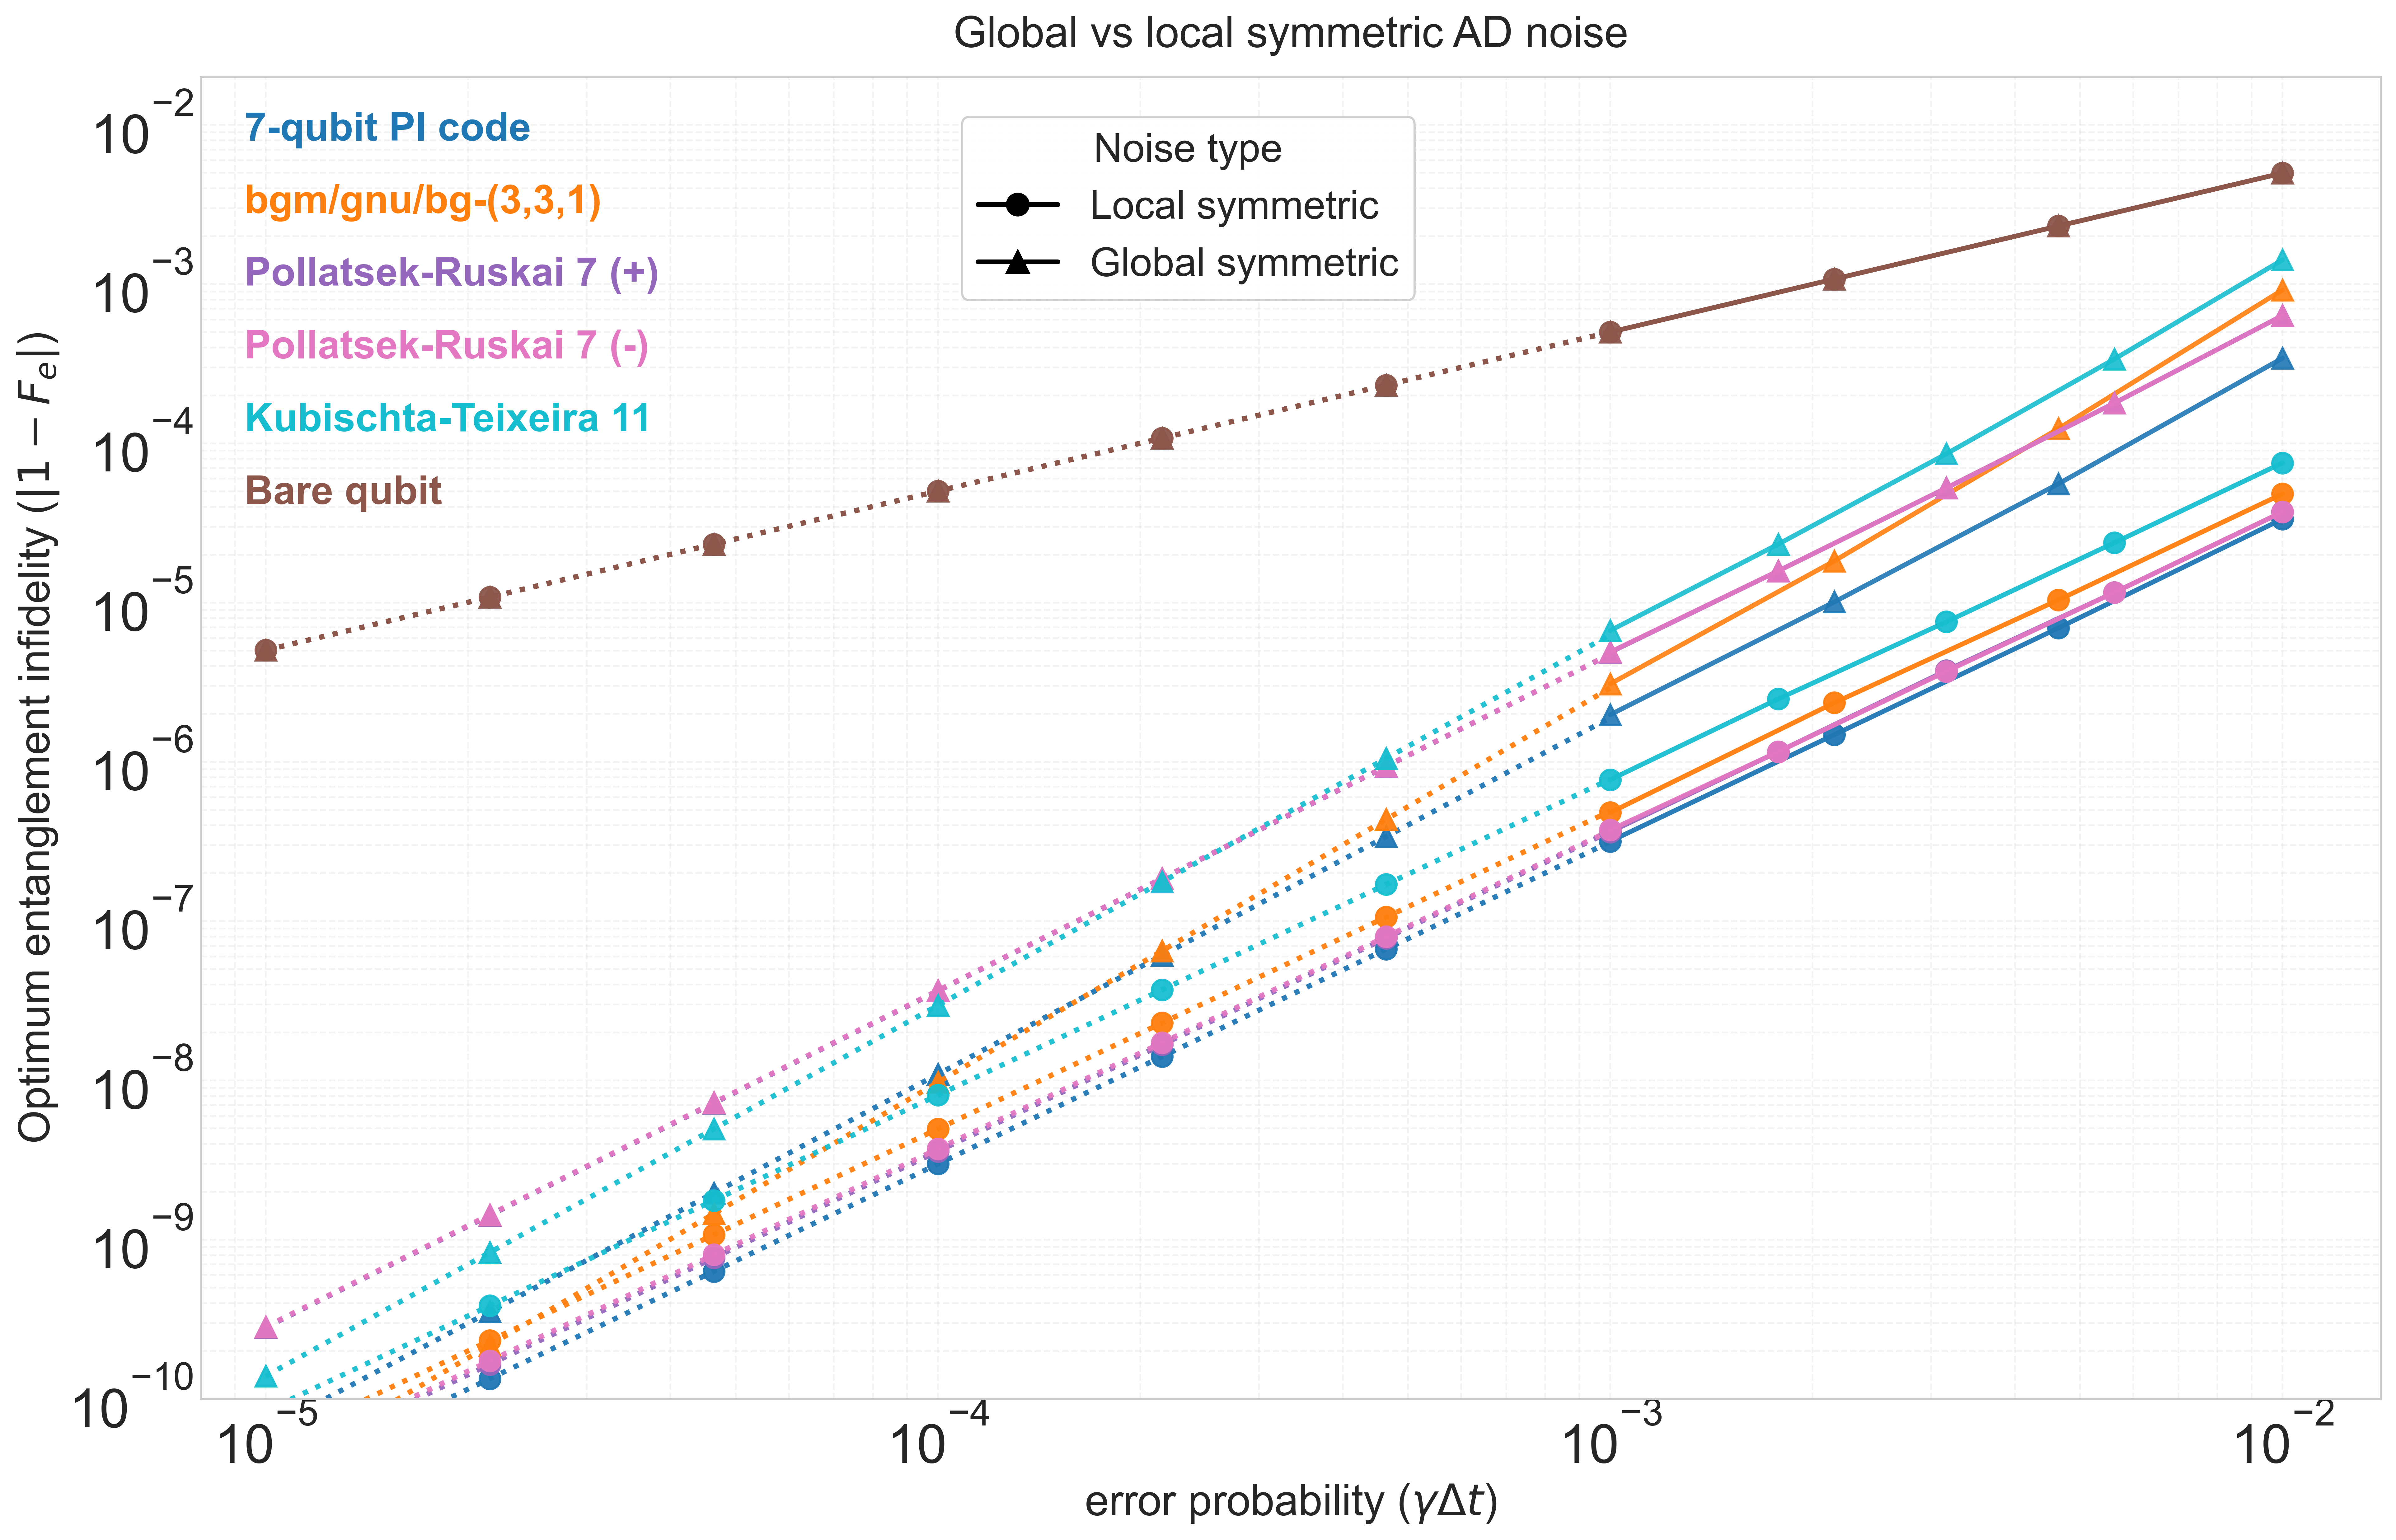

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use("seaborn-v0_8-whitegrid")

# -----------------------------------------------------------------------------
# Editable knobs
# -----------------------------------------------------------------------------
P_COLUMN = "gamma_dt"
FIT_SOURCE_MIN = 1e-3       # Points at/above this p are treated as computed data.
EXTRAPOLATE_TO = 1e-5       # Dotted extrapolation extends down to this p.
MIN_FIT_POINTS = 3
SAVE_FIGURE = True
FIGURE_STEM = "global_vs_local_symmetric_ad_new_codes_no_gross13"

# Remove or reorder entries here to change what appears in the plot.
# source="base" uses local_amp_damp_results.csv/global_amp_damp_results.csv.
# source="new" uses local_amp_damp_new_codes_results.csv/global_amp_damp_new_codes_results.csv.
CODE_SPECS = [
    {"prefix": "seven", "label": "7-qubit PI code", "source": "base", "color": "#1f77b4"},
    {"prefix": "bgm", "label": "bgm/gnu/bg-(3,3,1)", "source": "base", "color": "#ff7f0e"},
    {"prefix": "pr7_plus", "label": "Pollatsek-Ruskai 7 (+)", "source": "new", "color": "#9467bd"},
    {"prefix": "pr7_minus", "label": "Pollatsek-Ruskai 7 (-)", "source": "new", "color": "#e377c2"},
    {"prefix": "kt11", "label": "Kubischta-Teixeira 11", "source": "new", "color": "#17becf"},
    {"prefix": "bare", "label": "Bare qubit", "source": "base", "color": "#8c564b"},
    # Gross 13 intentionally removed.
    # {"prefix": "gross17", "label": "Gross 17-qubit", "source": "base", "color": "#2ca02c"},
]

NOISE_STYLE = {
    "local": {"marker": "o", "linestyle": "-", "alpha": 0.95, "label": "Local symmetric"},
    "global": {"marker": "^", "linestyle": "-", "alpha": 0.90, "label": "Global symmetric"},
}
FIT_LINESTYLE = ":"

TITLE = "Global vs local symmetric AD noise"
X_LABEL = r"error probability ($\gamma \Delta t$)"
Y_LABEL = r"Optimum entanglement infidelity ($|1 - F_e|$)"
X_LIMITS = (8e-6, 1.4e-2)
Y_LIMITS = (1e-10, 2e-2)

# -----------------------------------------------------------------------------
# Data loading
# -----------------------------------------------------------------------------
if "repo_root" not in globals():
    cwd = Path.cwd().resolve()
    repo_root = None
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "README.md").exists():
            repo_root = candidate
            break
    if repo_root is None:
        repo_root = cwd

if "data_dir" not in globals():
    data_dir = repo_root / "datas"

if "df_local" not in globals() or "df_global" not in globals():
    df_local = pd.read_csv(data_dir / "local_amp_damp_results.csv")
    df_global = pd.read_csv(data_dir / "global_amp_damp_results.csv")

if "df_local_new" not in globals() or "df_global_new" not in globals():
    df_local_new = pd.read_csv(data_dir / "local_amp_damp_new_codes_results.csv")
    df_global_new = pd.read_csv(data_dir / "global_amp_damp_new_codes_results.csv")

frames = {
    "base": {"local": df_local, "global": df_global},
    "new": {"local": df_local_new, "global": df_global_new},
}

for source_name, noise_frames in frames.items():
    for noise_name, frame in noise_frames.items():
        if P_COLUMN not in frame.columns:
            raise ValueError(f"{source_name}/{noise_name} data is missing '{P_COLUMN}'")

reference_low_p = np.sort(
    df_local.loc[
        np.isfinite(df_local[P_COLUMN])
        & (df_local[P_COLUMN] > 0)
        & (df_local[P_COLUMN] < FIT_SOURCE_MIN),
        P_COLUMN,
    ].to_numpy(dtype=float)
)
if reference_low_p.size == 0:
    reference_low_p = np.logspace(np.log10(EXTRAPOLATE_TO), np.log10(FIT_SOURCE_MIN), 7, endpoint=False)

# -----------------------------------------------------------------------------
# Plot helpers
# -----------------------------------------------------------------------------
def sorted_positive_series(frame, prefix):
    column = f"{prefix}_optimal"
    if column not in frame.columns:
        raise ValueError(f"Missing expected column '{column}'")

    data = frame[[P_COLUMN, column]].dropna()
    p = data[P_COLUMN].to_numpy(dtype=float)
    y = data[column].to_numpy(dtype=float)
    valid = np.isfinite(p) & np.isfinite(y) & (p > 0) & (y > 0)
    p = p[valid]
    y = y[valid]
    order = np.argsort(p)
    return p[order], y[order]


def fit_high_p(p, y):
    fit_mask = p >= FIT_SOURCE_MIN
    if np.count_nonzero(fit_mask) < MIN_FIT_POINTS:
        return None
    return np.polyfit(np.log10(p[fit_mask]), np.log10(y[fit_mask]), 1)


def extrapolation_points(p):
    low_p = reference_low_p[(reference_low_p >= EXTRAPOLATE_TO) & (reference_low_p < FIT_SOURCE_MIN)]
    if low_p.size == 0:
        low_p = np.logspace(np.log10(EXTRAPOLATE_TO), np.log10(FIT_SOURCE_MIN), 7, endpoint=False)
    line_p = np.logspace(np.log10(low_p.min()), np.log10(FIT_SOURCE_MIN), 100)
    return low_p, line_p

# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15.5, 10.0), dpi=500)

for spec in CODE_SPECS:
    prefix = spec["prefix"]
    color = spec["color"]
    source = spec["source"]

    for noise_name in ["local", "global"]:
        frame = frames[source][noise_name]
        style = NOISE_STYLE[noise_name]
        p, y = sorted_positive_series(frame, prefix)
        if p.size == 0:
            continue

        computed_mask = p >= FIT_SOURCE_MIN
        coeff = fit_high_p(p, y)

        if np.any(computed_mask):
            ax.loglog(
                p[computed_mask],
                y[computed_mask],
                color=color,
                marker=style["marker"],
                linestyle=style["linestyle"],
                ms=9.5,
                lw=2.2,
                alpha=style["alpha"],
            )

        if coeff is not None:
            low_p, line_p = extrapolation_points(p)
            line_y = 10 ** np.polyval(coeff, np.log10(line_p))
            marker_y = 10 ** np.polyval(coeff, np.log10(low_p))
            ax.loglog(line_p, line_y, color=color, linestyle=FIT_LINESTYLE, lw=2.4, alpha=0.95)
            ax.loglog(
                low_p,
                marker_y,
                color=color,
                marker=style["marker"],
                linestyle="None",
                ms=9.5,
                alpha=0.95,
            )

ax.set_title(TITLE, fontsize=20, pad=14)
ax.set_xlabel(X_LABEL, fontsize=20)
ax.set_ylabel(Y_LABEL, fontsize=20)
ax.set_xlim(*X_LIMITS)
ax.set_ylim(*Y_LIMITS)
ax.grid(True, which="both", ls="--", alpha=0.22)
ax.set_axisbelow(True)
ax.tick_params(axis="both", which="major", labelsize=25)

# Colored code labels. Change CODE_LABEL_Y_START / CODE_LABEL_DY if labels overlap.
CODE_LABEL_X = 0.02
CODE_LABEL_Y_START = 0.96
CODE_LABEL_DY = 0.055
for i, spec in enumerate(CODE_SPECS):
    ax.text(
        CODE_LABEL_X,
        CODE_LABEL_Y_START - i * CODE_LABEL_DY,
        spec["label"],
        transform=ax.transAxes,
        color=spec["color"],
        fontsize=18.5,
        fontweight="semibold",
        ha="left",
        va="center",
    )

noise_handles = [
    Line2D([0], [0], color="black", marker="o", linestyle="-", lw=2.2, ms=10, label=NOISE_STYLE["local"]["label"]),
    Line2D([0], [0], color="black", marker="^", linestyle="-", lw=2.2, ms=10, label=NOISE_STYLE["global"]["label"]),
]
ax.legend(
    handles=noise_handles,
    loc="upper left",
    bbox_to_anchor=(0.34, 0.985),
    frameon=True,
    framealpha=0.92,
    title="Noise type",
    fontsize=18.5,
    title_fontsize=18.5,
)

fig.tight_layout()

if SAVE_FIGURE:
    plot_dir = repo_root / "plots" / "AD"
    plot_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = plot_dir / f"{FIGURE_STEM}.pdf"
    png_path = plot_dir / f"{FIGURE_STEM}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")

plt.show()


# Pick a code and analyse the various cases
1. Now I will pick code say 3,3,1 bgm code and plot the local symmetric AD and global symmetric AD with and without the optimum recovery along with a bare qubit case. The aim of this plot is to send a message that encoding in PI codes is doing a great deal in error suppresion.  

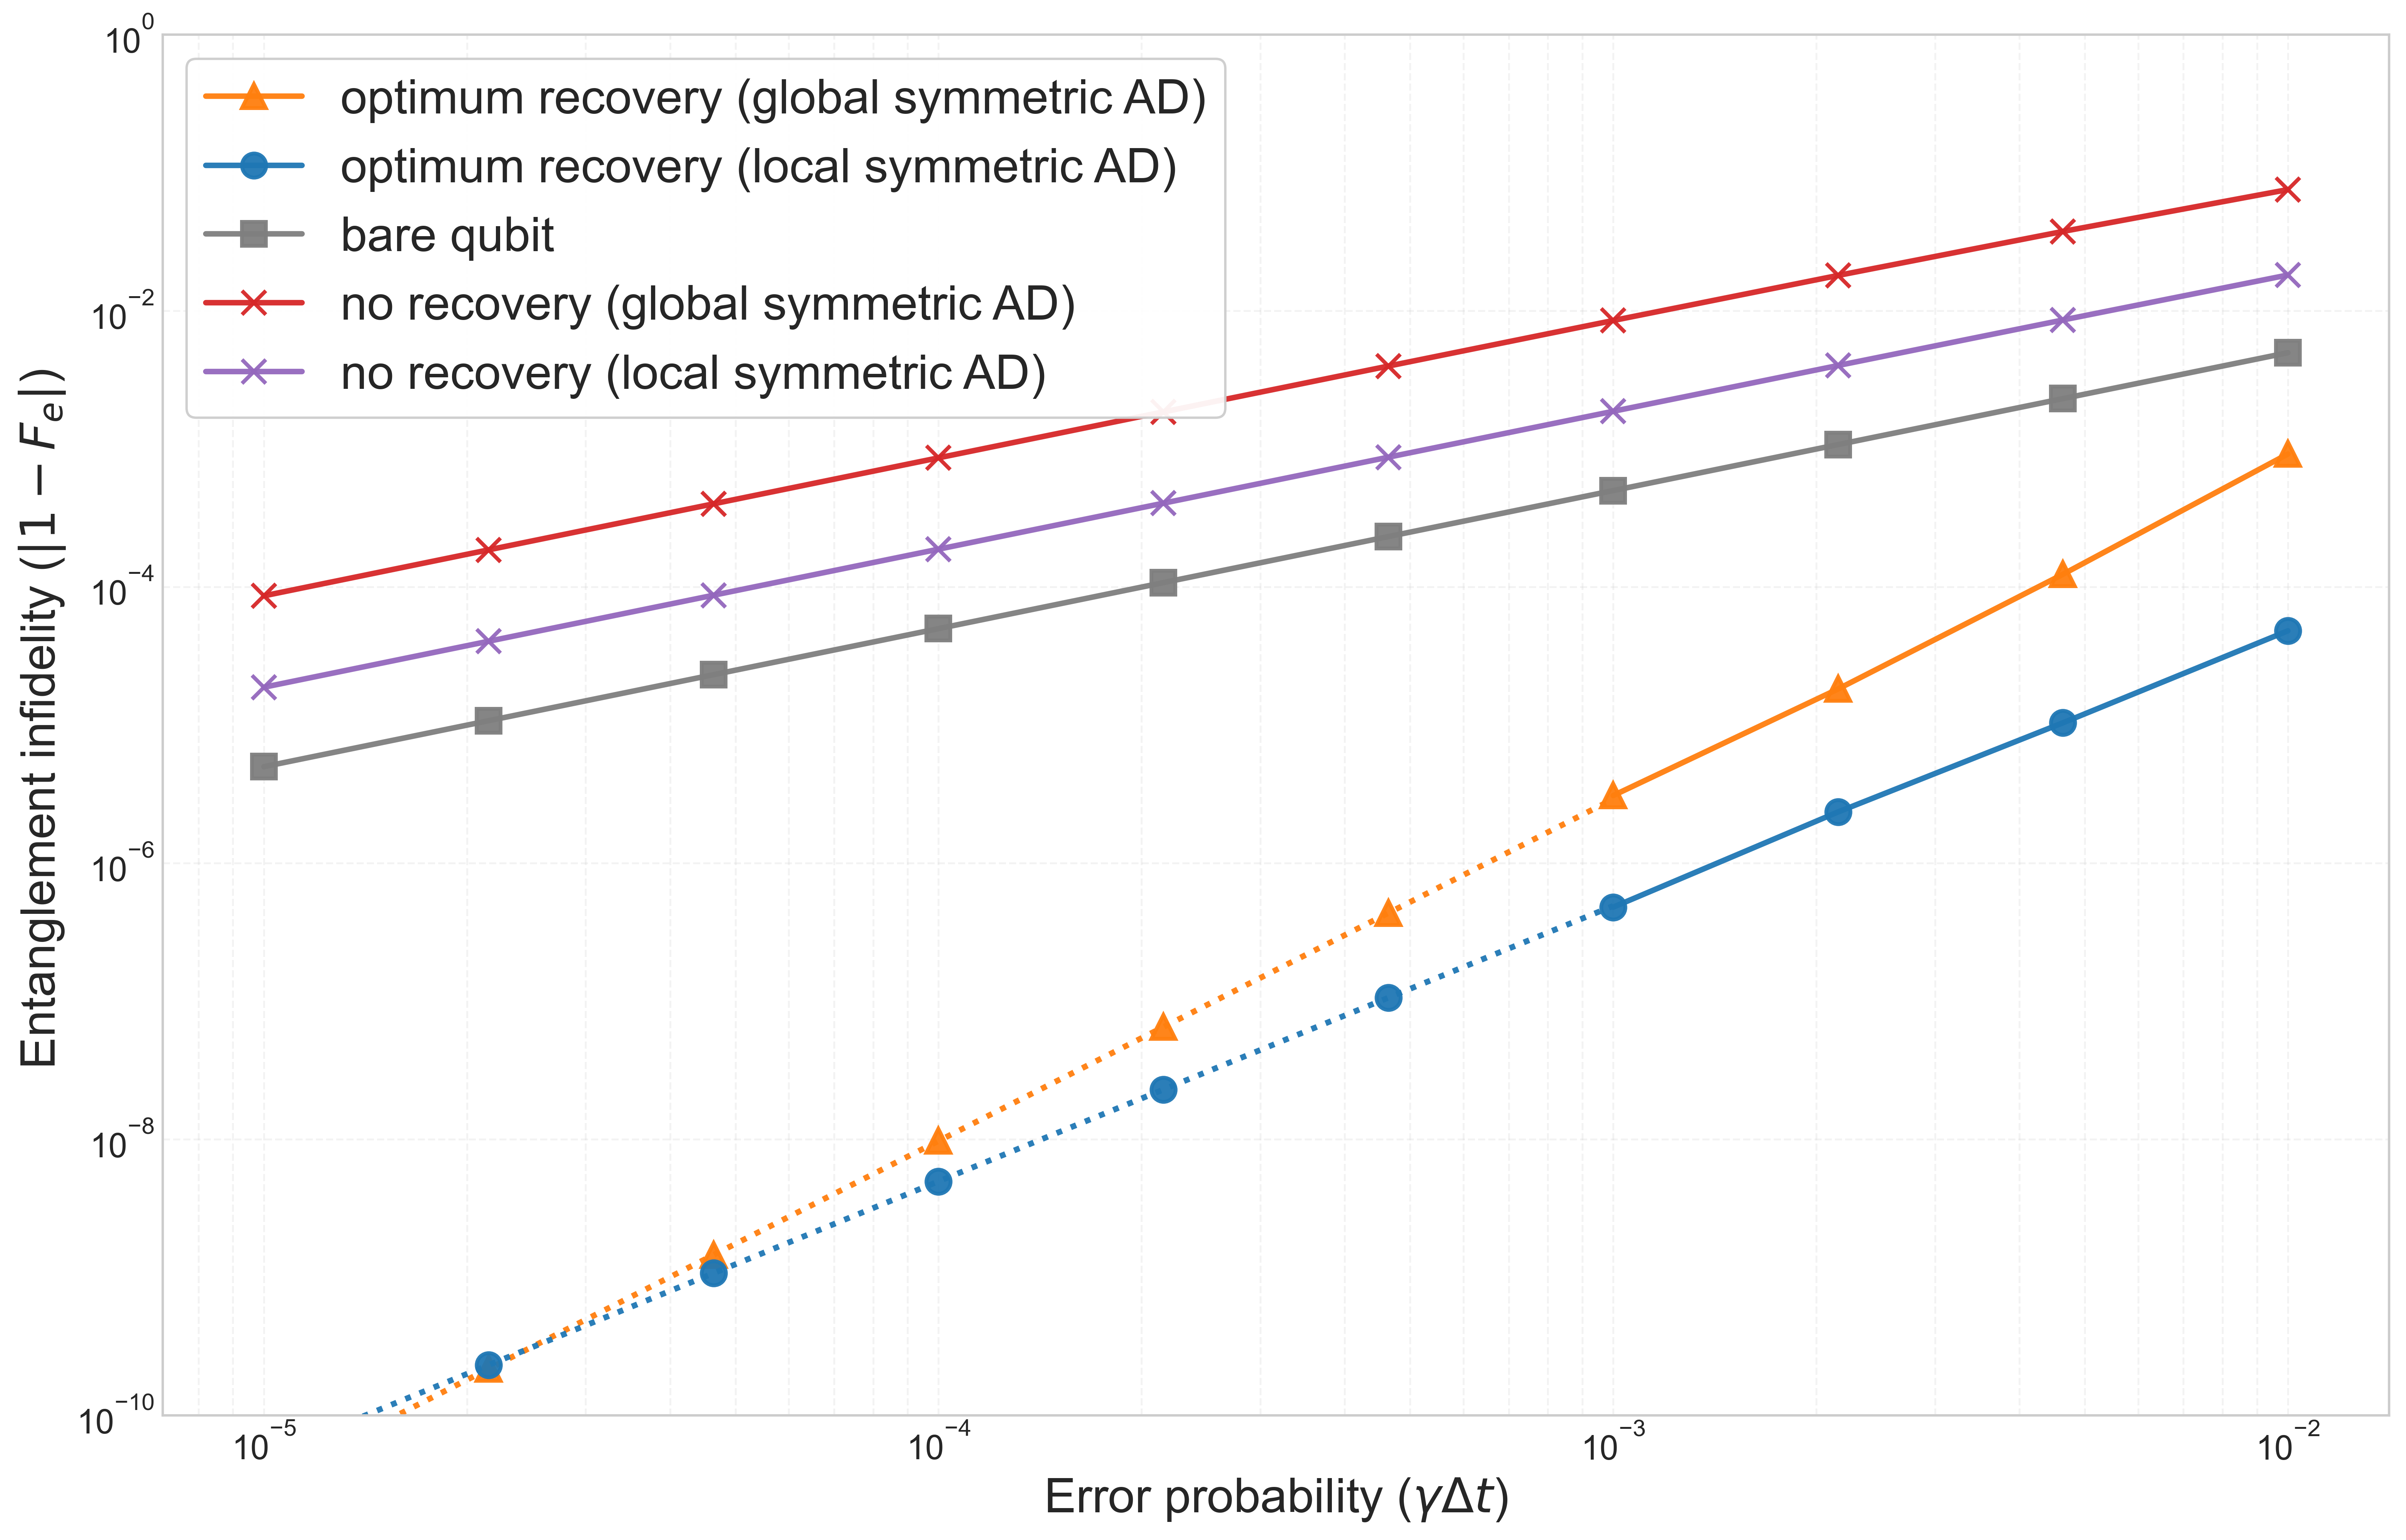

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

if "df_local" not in globals() or "df_global" not in globals():
    cwd = Path.cwd().resolve()
    repo_root = None
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "README.md").exists():
            repo_root = candidate
            break
    if repo_root is None:
        repo_root = cwd

    data_dir = repo_root / "datas"
    df_local = pd.read_csv(data_dir / "local_amp_damp_results.csv")
    df_global = pd.read_csv(data_dir / "global_amp_damp_results.csv")

code = "bgm"
fit_threshold = 5e-4
fit_source_min = 1e-3
min_fit_points = 3
fig, ax = plt.subplots(figsize=(14.0, 9.0), dpi=450)
marker_size = 10
legend_fontsize = 20.0

series_specs = [
    (df_global, f"{code}_optimal", "optimum recovery (global symmetric AD)", "#ff7f0e", "^", "#ff7f0e", True),
    (df_local, f"{code}_optimal", "optimum recovery (local symmetric AD)", "#1f77b4", "o", "#1f77b4", True),
    (df_local, "bare_optimal", "bare qubit", "#7f7f7f", "s", "#7f7f7f", False),
    (df_global, f"{code}_no_recovery", "no recovery (global symmetric AD)", "#d62728", "x", "#d62728", False),
    (df_local, f"{code}_no_recovery", "no recovery (local symmetric AD)", "#9467bd", "x", "#9467bd", False),
]

def split_and_fit_low_gamma(p, y):
    valid = np.isfinite(p) & np.isfinite(y) & (p > 0) & (y > 0)
    p = p[valid]
    y = y[valid]

    order = np.argsort(p)
    p = p[order]
    y = y[order]

    low_mask = p < fit_threshold
    high_mask = p >= fit_threshold
    fit_mask = p >= fit_source_min

    coeff = None
    if np.count_nonzero(fit_mask) >= min_fit_points and np.any(low_mask):
        coeff = np.polyfit(np.log10(p[fit_mask]), np.log10(y[fit_mask]), 1)

    return p, y, low_mask, high_mask, coeff

for frame, column, label, color, marker, markerfacecolor, use_fit in series_specs:
    if column not in frame.columns:
        raise ValueError(f"Missing expected column '{column}'")
    data = frame[["gamma_dt", column]].dropna()
    p = data["gamma_dt"].to_numpy(dtype=float)
    y = data[column].to_numpy(dtype=float)
    p, y, low_mask, high_mask, coeff = split_and_fit_low_gamma(p, y)

    if not use_fit:
        ax.loglog(
            p,
            y,
            color=color,
            marker=marker,
            linestyle="-",
            lw=2.3,
            ms=marker_size,
            markerfacecolor=markerfacecolor,
            markeredgecolor=color,
            markeredgewidth=1.6,
            alpha=0.95,
            label=label,
        )
        continue

    if np.any(high_mask):
        ax.loglog(
            p[high_mask],
            y[high_mask],
            color=color,
            marker=marker,
            linestyle="-",
            lw=2.3,
            ms=marker_size,
            markerfacecolor=markerfacecolor,
            markeredgecolor=color,
            markeredgewidth=1.6,
            alpha=0.95,
            label=label,
        )

    if np.any(low_mask) and coeff is not None:
        fit_end = p[high_mask].min() if np.any(high_mask) else fit_threshold
        p_fit = np.logspace(np.log10(p[low_mask].min()), np.log10(fit_end), 80)
        y_fit = 10 ** np.polyval(coeff, np.log10(p_fit))
        ax.loglog(
            p_fit,
            y_fit,
            color=color,
            linestyle=":",
            lw=2.4,
            alpha=0.95,
        )
        y_fit_pts = 10 ** np.polyval(coeff, np.log10(p[low_mask]))
        ax.loglog(
            p[low_mask],
            y_fit_pts,
            color=color,
            marker=marker,
            linestyle="None",
            ms=marker_size,
            markerfacecolor=markerfacecolor,
            markeredgecolor=color,
            markeredgewidth=1.6,
            alpha=0.95,
        )

#ax.set_title("3,3,1 BGM code: symmetric AD with and without optimum recovery", fontsize=18, pad=14)
ax.set_xlabel(r"Error probability ($\gamma \Delta t$)", fontsize=20)
ax.set_ylabel(r" Entanglement infidelity ($|1 - F_e|$)", fontsize=20)
ax.set_ylim(1e-10, 1.0)
ax.grid(True, which="both", ls="--", alpha=0.22)
ax.set_axisbelow(True)

ax.legend(
    loc="upper left",
    frameon=True,
    framealpha=0.94,
    fontsize=legend_fontsize,
)

ax.tick_params(axis="both", which="major", labelsize=14)
fig.tight_layout()
plt.show()
